Emerson Rodrigues Vero filho

Dsta Scientist


#### Definição do Problema ####

O objetivo deste trabalho é desenvolver um modelo de machine learning capaz de identificar automaticamente o tipo de superfície (como carpete, concreto ou madeira) com base em dados de sensores coletados durante o movimento de um robô. Esses sensores registram informações como aceleração, velocidade angular e orientação espacial. A partir desses sinais temporais, o modelo deve aprender padrões característicos de cada tipo de piso e ser capaz de generalizar para prever corretamente superfícies em novos cenários.


## 1 - Exploração (EDA) e pré-processamento dos dados.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import matplotlib.pyplot as plt
import optuna
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import acf
from sklearn.model_selection import ParameterGrid

In [ ]:
dataset = pd.read_csv("X_train_mod.csv")
dataset_anotado = pd.read_csv("y_train_mod.csv")
hold_out_dataset = pd.read_csv("X_test_mod.csv")

print(f"X_train: {dataset.shape}")
print(f"y_train: {dataset_anotado.shape}")
print(f"X_test:  {hold_out_dataset.shape}")

# não altera o dataset original
dataset_limpo = dataset.dropna(subset=["measurement_number"]).reset_index(drop=True)

def organize_timeseries(df, labels=None):
    df = df.dropna(subset=["row_id"]).copy()

    tmp = df["row_id"].str.split("_", n=1, expand=True)
    df["timeseries"] = tmp[0].astype(int)
    df["numerodoregistro"] = tmp[1].astype(int)

    cols = df.columns.tolist()
    cols.remove("timeseries")
    cols.remove("numerodoregistro")

    row_id_idx = cols.index("row_id") + 1
    new_cols = cols[:row_id_idx] + ["timeseries", "numerodoregistro"] + cols[row_id_idx:]

    return df[new_cols]

def add_sensor_magnitudes(df):
    df = df.copy()

    df["angular_velocity_mag"] = np.sqrt(
        df["angular_velocity_X"]**2 +
        df["angular_velocity_Y"]**2 +
        df["angular_velocity_Z"]**2
    )

    df["linear_acceleration_mag"] = np.sqrt(
        df["linear_acceleration_X"]**2 +
        df["linear_acceleration_Y"]**2 +
        df["linear_acceleration_Z"]**2
    )

    cols = list(df.columns)

    def move_after(col_name, after_col):
        cols.remove(col_name)
        idx = cols.index(after_col) + 1
        cols.insert(idx, col_name)

    move_after("angular_velocity_mag", "angular_velocity_Z")
    move_after("linear_acceleration_mag", "linear_acceleration_Z")

    return df[cols]

dataset_organizado = organize_timeseries(dataset_limpo)
dataset_incrementado = add_sensor_magnitudes(dataset_organizado)

#remocao de valores anomalos
def remove_anomalous_rows(df, col="numerodoregistro", group_col="timeseries", min_diff=0, max_diff=8):
    df = df.dropna(subset=[col]).copy()
    df = df.sort_values([group_col, col]).reset_index(drop=True)
    df["_diff"] = df.groupby(group_col)[col].diff()
    mask_anomalo = (df["_diff"] <= min_diff) | (df["_diff"] >= max_diff)
    df_limpo = df[~mask_anomalo].drop(columns=["_diff"]).reset_index(drop=True)
    print(f"Anomalos removidos: {mask_anomalo.sum()} | Registros mantidos: {len(df_limpo)}")
    return df_limpo

dataset_incrementado = remove_anomalous_rows(dataset_incrementado)

# Adicionar labels de surface usando y_train (dataset_anotado)
# (supondo series_id em dataset_anotado coincide com timeseries em dataset_incrementado)
if "series_id" in dataset_anotado.columns and "surface" in dataset_anotado.columns:
    dataset_labels = dataset_anotado.copy()
    dataset_labels["series_id"] = dataset_labels["series_id"].astype(int)
    dataset_incrementado = dataset_incrementado.merge(
        dataset_labels[["series_id", "surface"]],
        left_on="timeseries",
        right_on="series_id",
        how="left"
    )
    dataset_incrementado = dataset_incrementado.drop(columns=["series_id"], errors="ignore")

    # manter apenas registros com surface disponível
    dataset_filtrado = dataset_incrementado.dropna(subset=["surface"]).reset_index(drop=True)

print("Merge de surface efetuado:", "surface" in dataset_filtrado.columns)
print("Surface missing (depois do drop):", dataset_filtrado["surface"].isna().sum())
print("Linhas finais:", len(dataset_filtrado))

X_train: (492556, 13)
y_train: (3810, 3)
X_test:  (493332, 13)
Anomalos removidos: 4769 | Registros mantidos: 478100
Merge de surface efetuado: True
Surface missing (depois do drop): 0
Linhas finais: 473818


In [3]:
dataset_filtrado

,row_id,timeseries,numerodoregistro,series_id_x,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,angular_velocity_mag,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z,linear_acceleration_mag,series_id_y,surface
0,0_0,0,0,-0.010728,0.002334,-0.773039,-0.638283,-0.111479,-0.105607,0.099988,0.018410,0.005460,0.101815,-0.710255,2.099627,-9.746216,9.995079,0.0,fine_concrete
1,0_1,0,1,0.001013,0.990504,-0.750346,-0.630241,-0.096623,-0.102306,0.050083,0.042082,0.004863,0.065597,0.335449,1.487888,-9.406142,9.529001,0.0,fine_concrete
2,0_2,0,2,-0.007640,1.990773,-0.754367,-0.635299,-0.106324,-0.110166,0.001823,0.043896,-0.006134,0.044360,-0.262025,1.587835,-8.725550,8.872716,0.0,fine_concrete
3,0_3,0,3,-0.001271,2.979143,-0.759495,-0.643595,-0.115643,-0.101742,0.002906,-0.007165,-0.015861,0.017646,0.421174,1.088723,-10.113493,10.180641,0.0,fine_concrete
4,0_4,0,4,0.008142,3.998463,-0.751108,-0.647003,-0.120263,-0.126985,0.016671,0.004646,0.005801,0.018253,-5.134896,1.460306,-10.437720,11.723722,0.0,fine_concrete
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473813,3809_123,3809,123,3808.991482,123.005995,0.635280,-0.766787,-0.081376,0.090876,-0.002933,0.095334,-0.139423,0.168926,3.274864,2.009123,-9.002089,9.787692,3809.0,soft_pvc
473814,3809_124,3809,124,3809.016281,123.993371,0.624273,-0.757888,-0.090722,0.078521,0.005065,0.032734,-0.142842,0.146632,4.453029,3.069532,-8.130935,9.765429,3809.0,soft_pvc
473815,3809_125,3809,125,3809.013897,125.000846,0.622418,-0.757093,-0.070087,0.096437,-0.034230,0.002814,-0.135024,0.139324,2.699827,4.238132,-8.143185,9.568819,3809.0,soft_pvc
473816,3809_126,3809,126,3809.007257,126.000454,0.644011,-0.768166,-0.086862,0.102385,-0.060282,-0.005200,-0.140074,0.152584,2.535974,4.723545,-9.431971,10.849199,3809.0,soft_pvc


In [4]:
one_data=dataset_organizado[dataset_organizado["timeseries"] == 6].head()
one_data

,row_id,timeseries,numerodoregistro,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
763,6_0,6,0,6.010971,0.018717,-4.076611,-0.880869,-0.147429,-0.052177,0.034282,0.024732,-0.030570,0.103464,3.294834,-8.353144
764,6_1,6,1,6.007579,1.002993,-0.404479,-0.903442,-0.123701,-0.049351,0.004848,0.014153,-0.013237,1.426662,2.301941,-9.203519
765,6_2,6,2,5.983460,1.994626,-0.413309,-0.900024,-0.144291,-0.056230,0.008095,0.001457,-0.001592,0.148731,1.915393,-10.016802
766,6_3,6,3,6.003942,3.001110,-0.394299,-0.893923,-0.140963,-0.053484,0.051177,0.002186,-0.020745,-0.031363,2.168306,-10.105237
767,6_4,6,4,6.013617,4.000314,-0.407326,-0.907729,-0.130171,-0.035402,0.056166,0.018763,-0.042168,0.611161,2.434669,-9.750459


Visualizacao dos Dados para uma serie temporal

Colunas a plotar: ['series_id_x', 'orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W', 'angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z', 'angular_velocity_mag', 'linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z', 'linear_acceleration_mag', 'series_id_y']


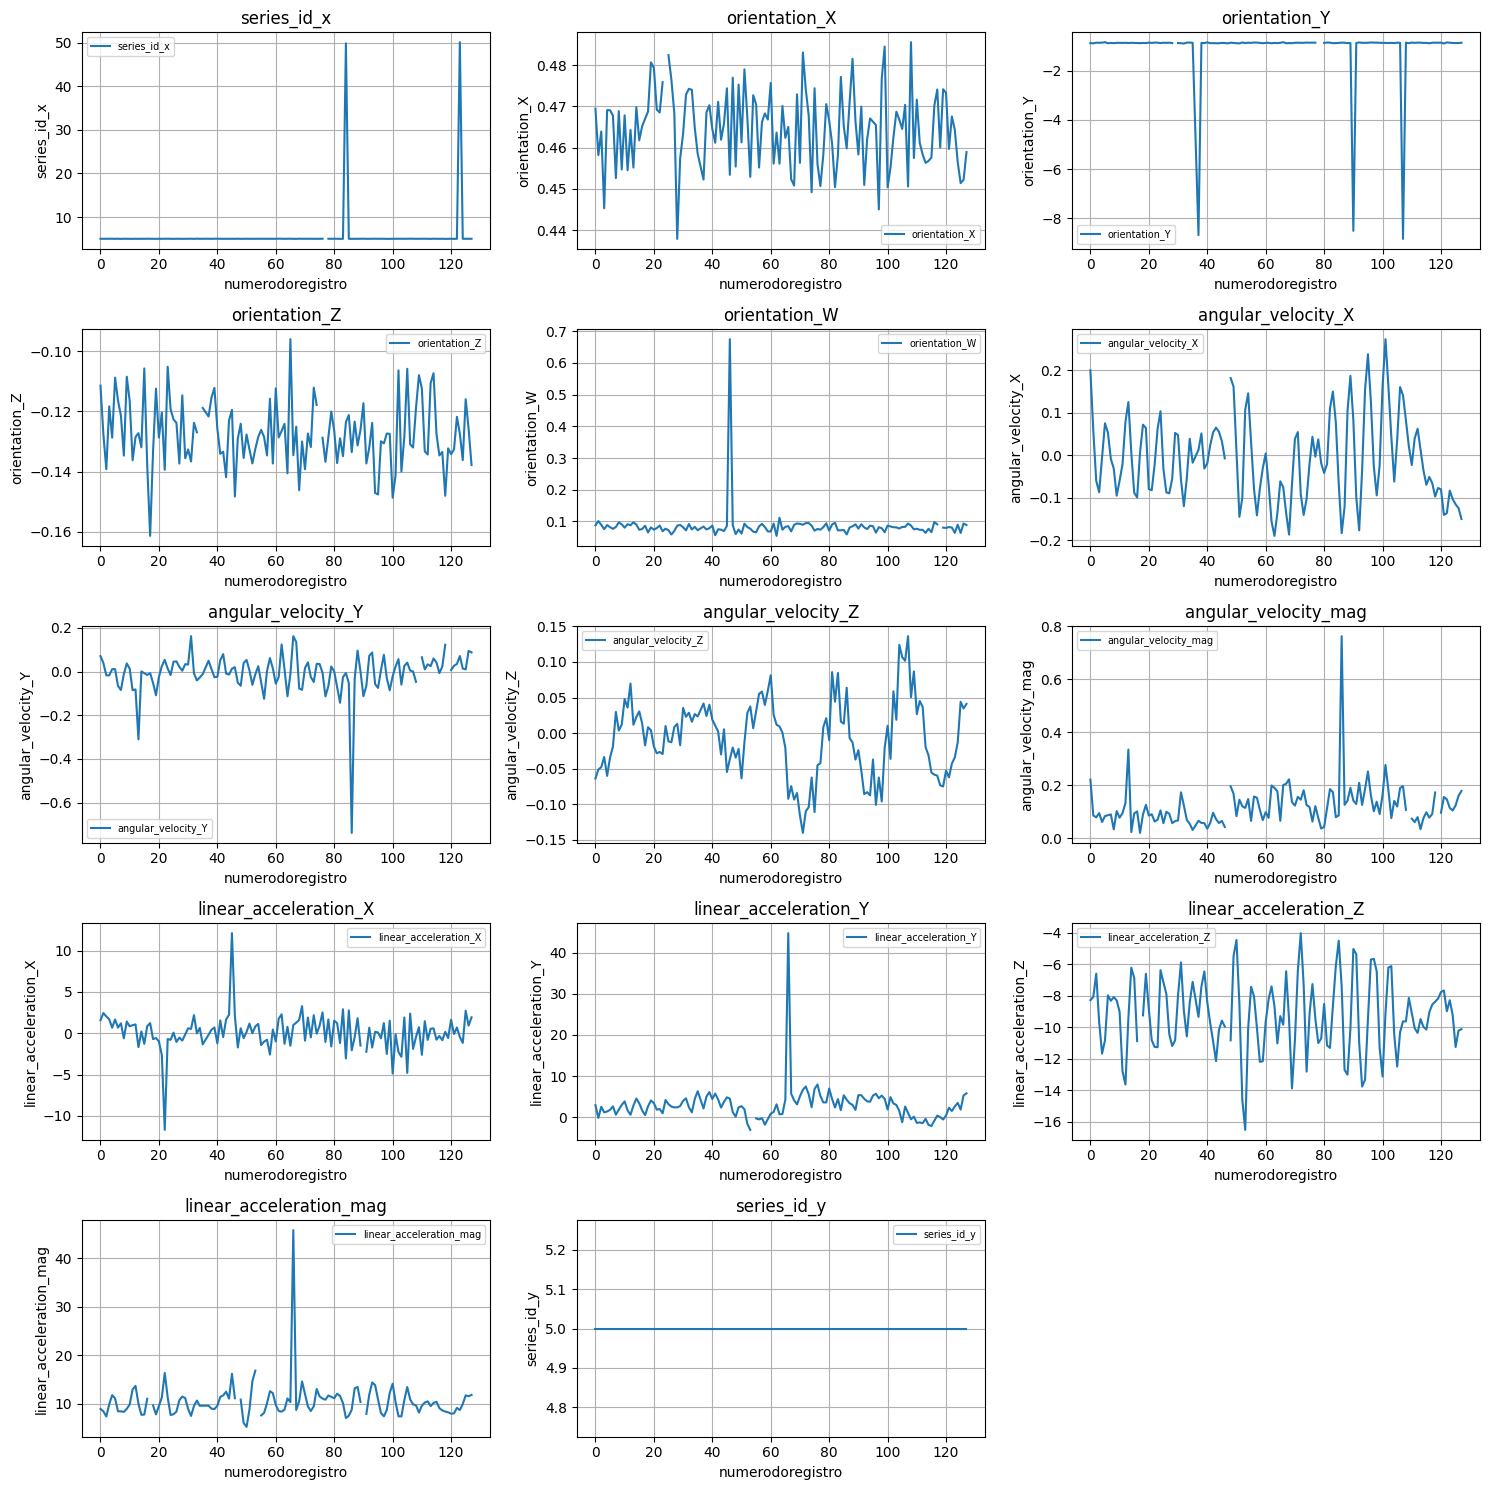

Colunas de orientation: ['orientation_X', 'orientation_Y', 'orientation_Z', 'orientation_W']


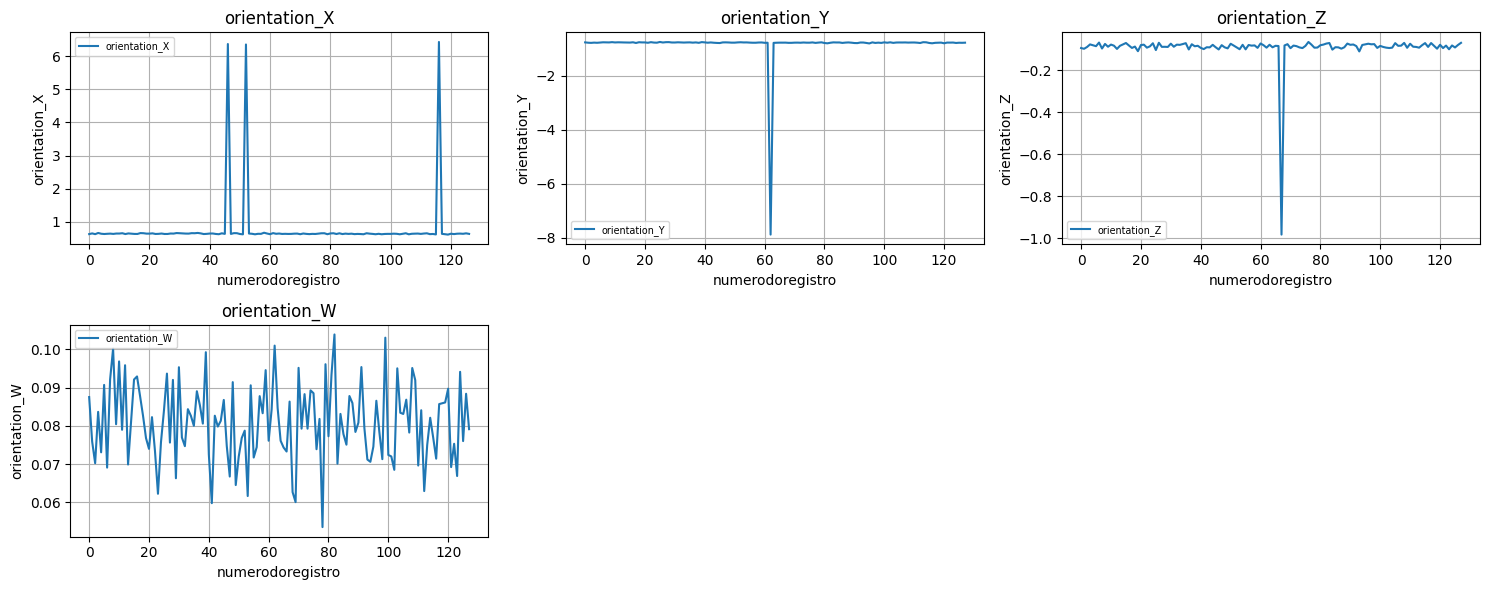

Colunas de angular_velocity: ['angular_velocity_X', 'angular_velocity_Y', 'angular_velocity_Z', 'angular_velocity_mag']


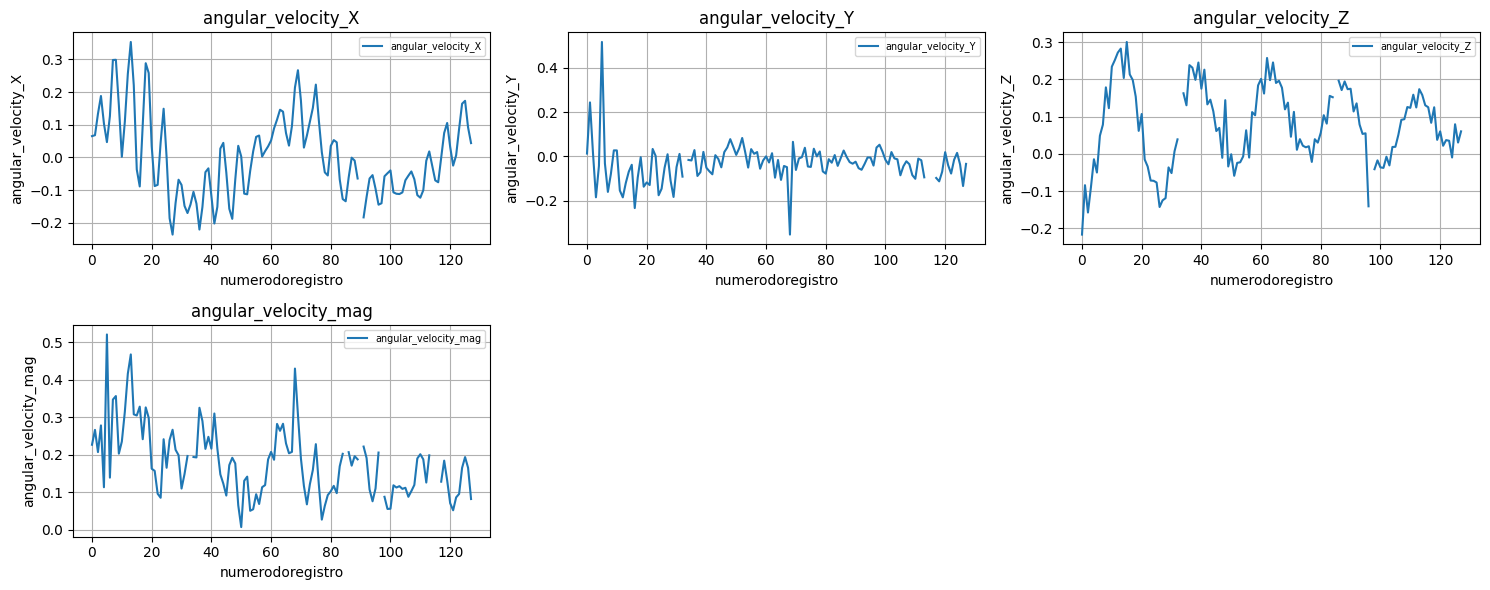

Colunas de linear_acceleration: ['linear_acceleration_X', 'linear_acceleration_Y', 'linear_acceleration_Z', 'linear_acceleration_mag']


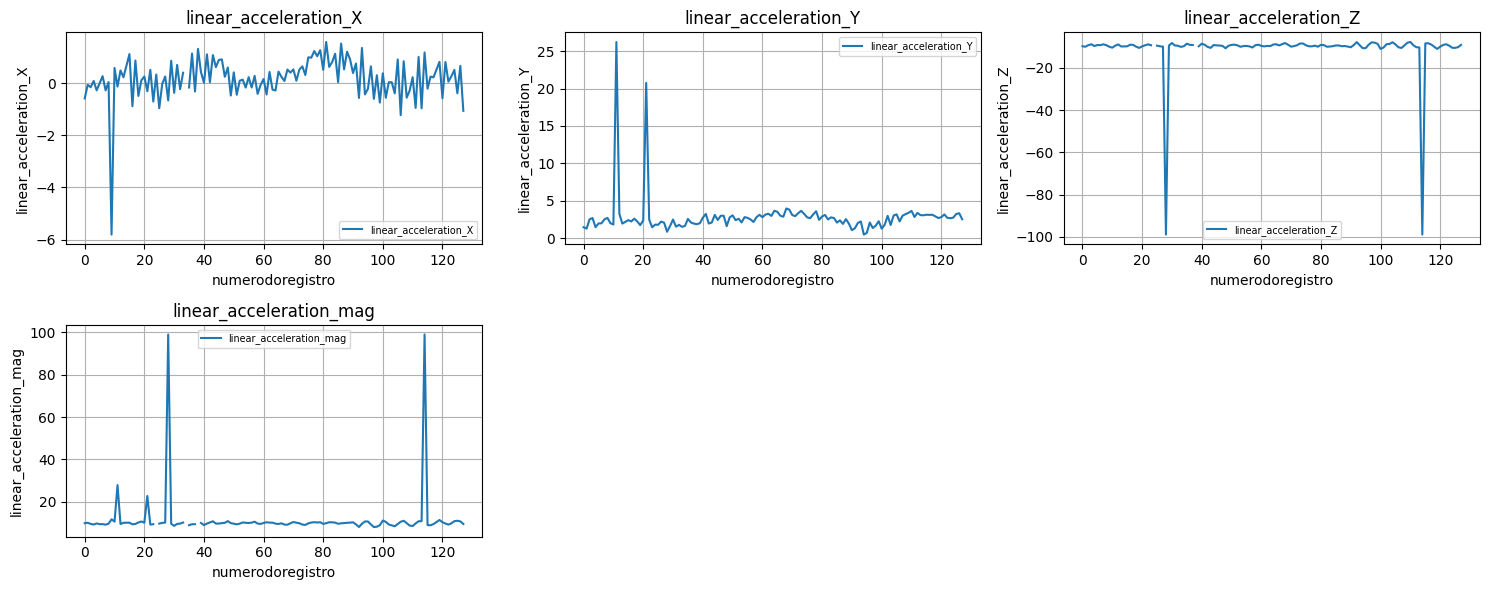

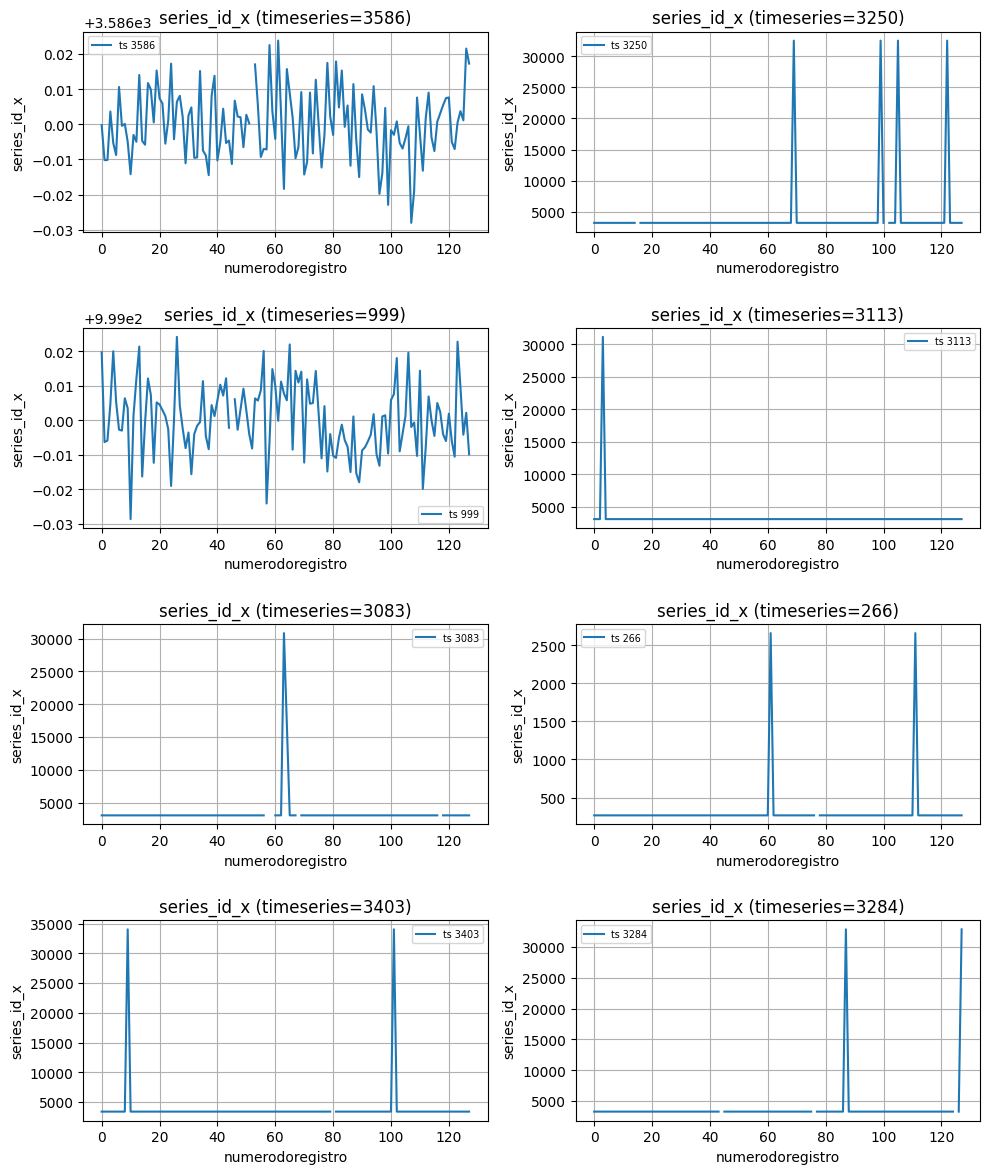

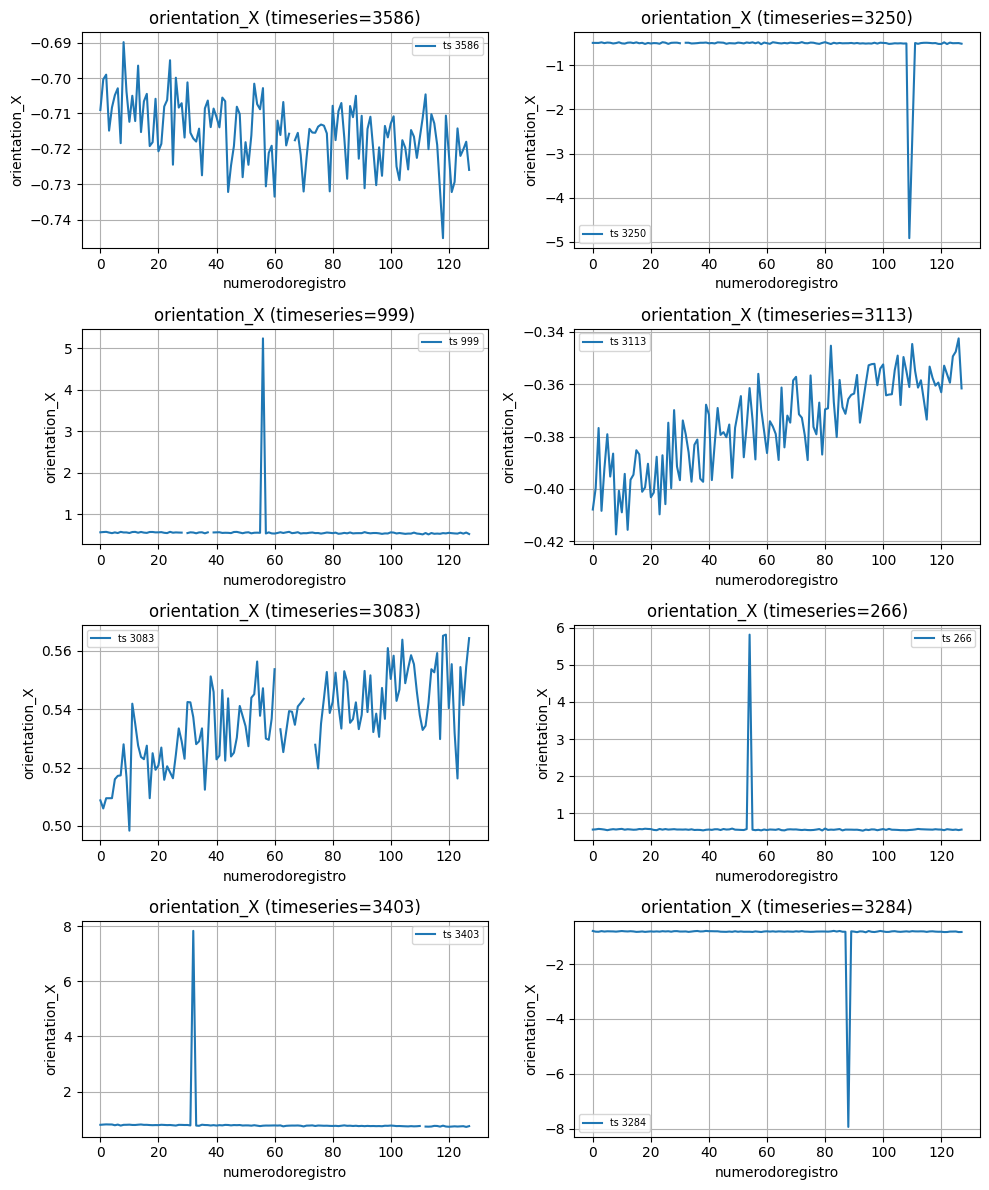

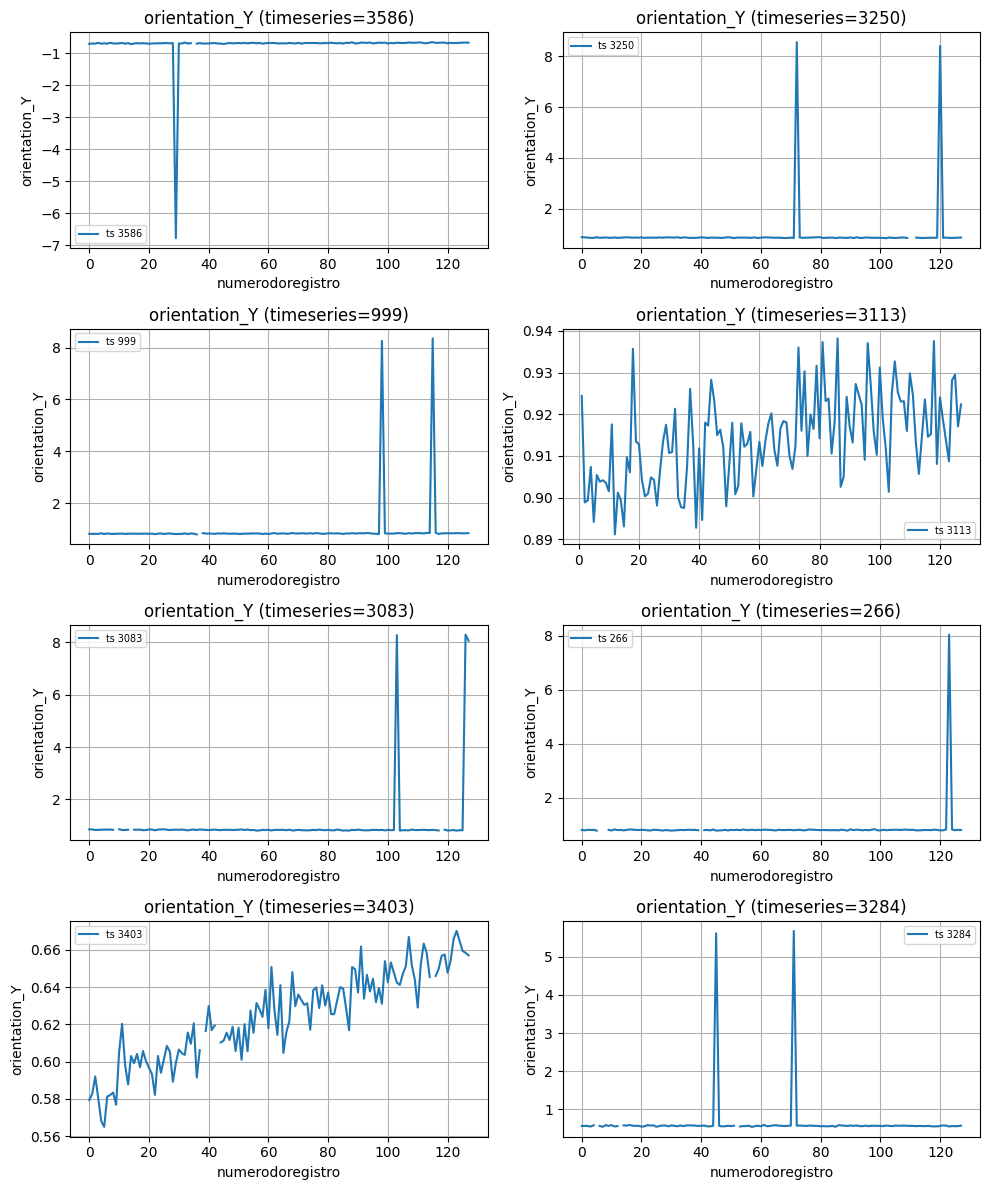

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: todas as features para timeseries 5 ---
index = 5
onedata = dataset_filtrado[dataset_filtrado["timeseries"] == index]
colunas = [c for c in onedata.columns if c not in ["row_id","timeseries","numerodoregistro","measurement_number","surface","series_id"]]
print("Colunas a plotar:", colunas)
n = len(colunas)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(5*cols, 3*rows))
for i, col in enumerate(colunas, 1):
    ax = plt.subplot(rows, cols, i)
    ax.plot(onedata["numerodoregistro"], onedata[col], label=col)
    ax.set_title(col)
    ax.set_xlabel("numerodoregistro")
    ax.set_ylabel(col)
    ax.grid(True)
    ax.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# --- Plot 2: orientacao para timeseries 3100 ---
index = 3100
onedata = dataset_filtrado[dataset_filtrado["timeseries"] == index]
orientation_cols = [c for c in onedata.columns if c.startswith("orientation_")]
print("Colunas de orientation:", orientation_cols)
n = len(orientation_cols)
rows = (n + cols - 1) // cols
plt.figure(figsize=(5*cols, 3*rows))
for i, col in enumerate(orientation_cols, 1):
    ax = plt.subplot(rows, cols, i)
    ax.plot(onedata["numerodoregistro"], onedata[col], label=col)
    ax.set_title(col)
    ax.set_xlabel("numerodoregistro")
    ax.set_ylabel(col)
    ax.grid(True)
    ax.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# --- Plot 3: velocidade angular para timeseries 3200 ---
index = 3200
onedata = dataset_filtrado[dataset_filtrado["timeseries"] == index]
angular_cols = [c for c in onedata.columns if c.startswith("angular_velocity_")]
print("Colunas de angular_velocity:", angular_cols)
n = len(angular_cols)
rows = (n + cols - 1) // cols
plt.figure(figsize=(5*cols, 3*rows))
for i, col in enumerate(angular_cols, 1):
    ax = plt.subplot(rows, cols, i)
    ax.plot(onedata["numerodoregistro"], onedata[col], label=col)
    ax.set_title(col)
    ax.set_xlabel("numerodoregistro")
    ax.set_ylabel(col)
    ax.grid(True)
    ax.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# --- Plot 4: aceleracao linear para timeseries 3100 ---
index = 3100
onedata = dataset_filtrado[dataset_filtrado["timeseries"] == index]
accel_cols = [c for c in onedata.columns if c.startswith("linear_acceleration_")]
print("Colunas de linear_acceleration:", accel_cols)
n = len(accel_cols)
rows = (n + cols - 1) // cols
plt.figure(figsize=(5*cols, 3*rows))
for i, col in enumerate(accel_cols, 1):
    ax = plt.subplot(rows, cols, i)
    ax.plot(onedata["numerodoregistro"], onedata[col], label=col)
    ax.set_title(col)
    ax.set_xlabel("numerodoregistro")
    ax.set_ylabel(col)
    ax.grid(True)
    ax.legend(fontsize="x-small")
plt.tight_layout()
plt.show()

# --- Plot 5: series aleatorias por coluna ---
def plot_random_timeseries_for_column(df, col_index=0, n_series=10, random_state=42, cols=5):
    feature_cols = [c for c in df.columns if c not in ["row_id","timeseries","numerodoregistro","measurement_number","surface","series_id"]]
    if col_index < 0 or col_index >= len(feature_cols):
        raise IndexError(f"col_index deve estar entre 0 e {len(feature_cols)-1}")
    feature_name = feature_cols[col_index]
    series_ids = df["timeseries"].unique()
    rng = np.random.default_rng(random_state)
    chosen = rng.choice(series_ids, size=min(n_series, len(series_ids)), replace=False)
    rows = (len(chosen) + cols - 1) // cols
    plt.figure(figsize=(5*cols, 3*rows))
    for i, ts in enumerate(chosen, 1):
        sub = df[df["timeseries"] == ts]
        ax = plt.subplot(rows, cols, i)
        ax.plot(sub["numerodoregistro"], sub[feature_name], label=f"ts {ts}")
        ax.set_title(f"{feature_name} (timeseries={ts})")
        ax.set_xlabel("numerodoregistro")
        ax.set_ylabel(feature_name)
        ax.grid(True)
        ax.legend(fontsize="x-small")
    plt.tight_layout()
    plt.show()

plot_random_timeseries_for_column(dataset_filtrado, col_index=0, n_series=8, random_state=13, cols=2)
plot_random_timeseries_for_column(dataset_filtrado, col_index=1, n_series=8, random_state=13, cols=2)
plot_random_timeseries_for_column(dataset_filtrado, col_index=2, n_series=8, random_state=13, cols=2)


## Variaveias a serem extraidas


1. Estatísticas básicas (momento 1-4 + percentis)
mean, std, min, max, median, q25, q75, iqr, range
capturam localização e dispersão, mais robustos para outliers.
explicam magnitude e amplitude do sensor na sequência.
2. Assimetria / forma
skew, kurtosis
diária se sinais são simétricos, picos, caudas.
diferente tipo de piso tende a produzir perfis de aceleração/giroscópio distintos em distribuição.
3. Dinâmica local (diferenças)
mean_abs_change, mean_change, max_abs_change, sum_abs_diff
detalhe sobre variações instantâneas (velocidade de mudança, flare / choque).
útil para o robô perceber instabilidade em superfície (por ex., menor amortecimento em piso duro).
4. Padrões de zero crossing e energia
zero_crossings: medida de oscilação/freqüência em tempo.
signal_energy: soma dos quadrados, intensidade total do movimento.
5. FFT (frequências)
fft_mean/std/max/energy/dominant_freq + primeiros fft_i
capturam periodicidade / vibração (superfícies têm conteúdo espectral característico).
dominant_freq identifica frequência dominante (andamento do motor + reverberação do solo).
6. Autocorrelação (ACF)
acf_lag1/2/3/5/10, acf_max/argmax/sum/energy/significant_count/first_zero_cross
medem memória temporal e ritmo.
piso estável → alto autocorrel em lags baixos; piso irregular → cai rápido.
verificam estrutura de dependência sequencial além de ruído.
7. Rótulos e IDs
surface é target.
series_id (aqui setado como unknown_variable2) para identificar série.
garante que cada linha de features representa uma série e pode ser mergeada com y.
Racional geral
Estatísticas globais + medidas de variação (time-domain) geram robustez em ML clássico.
FFT + ACF capturam comportamento temporal/frequencial que diferencia superfícies.
As features são multi-resolução: estática (moments), transiente (diff), harmônica (FFT), resoluções de dependência (ACF).

In [ ]:


sensor_cols = [
    "orientation_X","orientation_Y","orientation_Z","orientation_W",
    "angular_velocity_X","angular_velocity_Y","angular_velocity_Z", "angular_velocity_mag",
    "linear_acceleration_X","linear_acceleration_Y","linear_acceleration_Z", "linear_acceleration_mag"
]

def extract_all_features(ts_df, sensor_cols, max_lag=20, n_fft_features=10):
    features = {}
    for col in sensor_cols:
        x = ts_df[col].dropna().values
        if len(x) == 0:
            continue

        mean = np.mean(x)
        std = np.std(x)
        min_v = np.min(x)
        max_v = np.max(x)
        median = np.median(x)
        q25 = np.quantile(x, 0.25)
        q75 = np.quantile(x, 0.75)

        features[f"{col}_mean"] = mean
        features[f"{col}_std"] = std
        features[f"{col}_min"] = min_v
        features[f"{col}_max"] = max_v
        features[f"{col}_median"] = median
        features[f"{col}_range"] = max_v - min_v
        features[f"{col}_skew"] = skew(x)
        features[f"{col}_kurtosis"] = kurtosis(x)
        features[f"{col}_q25"] = q25
        features[f"{col}_q75"] = q75
        features[f"{col}_iqr"] = q75 - q25

        if len(x) > 1:
            diff = np.diff(x)
            features[f"{col}_mean_abs_change"] = np.mean(np.abs(diff))
            features[f"{col}_mean_change"] = np.mean(diff)
            features[f"{col}_max_abs_change"] = np.max(np.abs(diff))
            features[f"{col}_sum_abs_diff"] = np.sum(np.abs(diff))
            if len(x) > 2:
                features[f"{col}_mean_second_derivative"] = np.mean(np.diff(x, 2))
            else:
                features[f"{col}_mean_second_derivative"] = np.nan

        features[f"{col}_zero_crossings"] = np.sum(np.diff(np.sign(x)) != 0)
        features[f"{col}_signal_energy"] = np.sum(x**2)

        fft_vals = np.abs(np.fft.rfft(x))
        features[f"{col}_fft_mean"] = np.mean(fft_vals)
        features[f"{col}_fft_std"] = np.std(fft_vals)
        features[f"{col}_fft_max"] = np.max(fft_vals)
        features[f"{col}_fft_energy"] = np.sum(fft_vals**2)
        features[f"{col}_fft_dominant_freq"] = np.argmax(fft_vals)

        for i in range(1, n_fft_features + 1):
            features[f"{col}_fft_{i}"] = fft_vals[i] if i < len(fft_vals) else np.nan

        if len(x) > max_lag:
            acf_vals = acf(x, nlags=max_lag, fft=True)
            for lag in [1,2,3,5,10]:
                if lag <= max_lag:
                    features[f"{col}_acf_lag{lag}"] = acf_vals[lag]
            features[f"{col}_acf_max"] = np.max(acf_vals[1:])
            features[f"{col}_acf_argmax"] = np.argmax(acf_vals[1:]) + 1
            features[f"{col}_acf_sum_{max_lag}"] = np.sum(acf_vals[1:])
            features[f"{col}_acf_energy"] = np.sum(acf_vals[1:]**2)
            features[f"{col}_acf_significant_count"] = np.sum(np.abs(acf_vals[1:]) > 0.2)
            zero_cross = np.where(np.diff(np.sign(acf_vals)))[0]
            features[f"{col}_acf_first_zero_cross"] = zero_cross[0] if len(zero_cross) > 0 else max_lag

    features["surface"] = ts_df["surface"].iloc[0]
    features["series_id"] = ts_df["measurement_number"].iloc[0]
    return pd.DataFrame([features])

alldata = []
timeseries_ids = dataset_filtrado["timeseries"].unique()  # [0,1,3,5,...] possivelmente não contínuo
for ts in timeseries_ids:
    onedata = dataset_filtrado[dataset_filtrado["timeseries"] == ts]
    if onedata.empty:
        continue
    features = extract_all_features(onedata, sensor_cols)
    alldata.append(features)


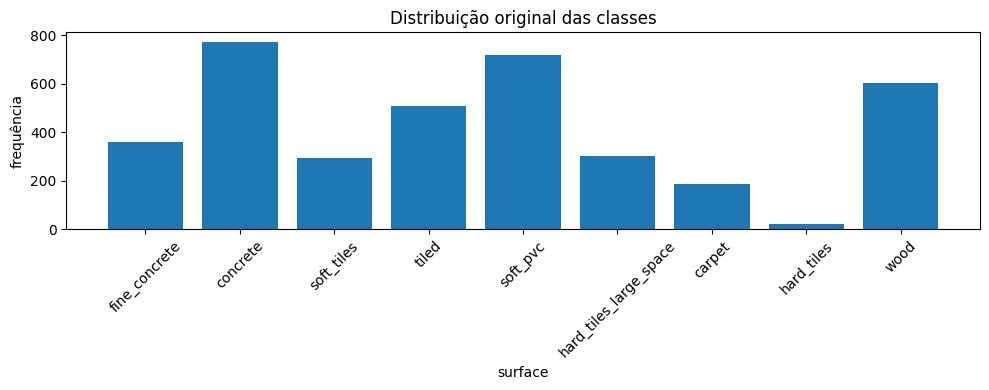

In [7]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def random_split(alldata, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, random_state=42):

    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("As proporções devem somar 1.0")

    # classes para histograma
    classes = [df["surface"].iloc[0] for df in alldata]

    contagem = Counter(classes)

    plt.figure(figsize=(10,4))
    plt.bar(contagem.keys(), contagem.values())
    plt.title("Distribuição original das classes")
    plt.xlabel("surface")
    plt.ylabel("frequência")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # embaralhar lista
    rng = np.random.default_rng(random_state)
    shuffled = alldata.copy()
    rng.shuffle(shuffled)

    n = len(shuffled)

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train = shuffled[:n_train]
    val = shuffled[n_train:n_train + n_val]
    test = shuffled[n_train + n_val:]

    return [train, val, test]

train, val, test = random_split(alldata)

## Escolha de Metrica de Avaliaçao adequada para o problema

Uma métrica adequada para avaliar este projeto é o F1 macro, pois o problema consiste em uma classificação multiclasse em que o modelo deve identificar corretamente diferentes tipos de superfície. Nesse contexto, não é suficiente avaliar apenas a acurácia global, pois ela pode ser influenciada pelo número de exemplos de cada classe. Caso algumas superfícies apareçam com maior frequência no conjunto de dados, um modelo pode apresentar uma acurácia elevada mesmo tendo desempenho ruim em classes menos representadas.

O F1 macro contorna esse problema ao calcular o F1-score individualmente para cada classe e, em seguida, realizar a média simples entre todas elas. Dessa forma, cada superfície recebe o mesmo peso na avaliação, independentemente de sua frequência no dataset. O F1-score, por sua vez, combina precision (o quão confiáveis são as previsões de uma classe) e recall (o quanto o modelo consegue identificar os exemplos reais daquela classe), penalizando simultaneamente falsos positivos e falsos negativos.

Assim, utilizar o F1 macro permite avaliar de forma mais equilibrada o desempenho do modelo, garantindo que ele apresente boa capacidade de identificação para todas as superfícies, e não apenas para aquelas mais frequentes no conjunto de dados. Essa característica é particularmente importante em aplicações de classificação multiclasse, nas quais o objetivo é obter um modelo robusto e consistente entre diferentes categorias.

## Descriçao do algoritimo e justificativa da escolha dos modelos.(métricas de avaliação, performance, descrição do algoritmo etc...)

O XGBoost foi utilizado por ser um algoritmo de gradient boosting baseado em árvores, conhecido por apresentar alto desempenho em dados tabulares estruturados. Ele é capaz de capturar relações não lineares e interações complexas entre variáveis, algo importante em dados de sensores como orientação, velocidade angular e aceleração. Além disso, possui mecanismos de regularização que ajudam a evitar overfitting, boa eficiência computacional e permite analisar a importância das variáveis, auxiliando na interpretação do modelo.

Os dados anotados foram divididos em 60% treino, 20% validação e 20% teste. Como apenas o training set estava anotado, foi necessário realizar essa divisão a partir dele, garantindo conjuntos separados para treinamento, ajuste e avaliação do modelo.

O conjunto de treinamento é utilizado para ajustar os parâmetros do modelo. Já o conjunto de validação é essencial para selecionar hiperparâmetros e comparar diferentes configurações, permitindo monitorar o desempenho em dados não vistos durante o treinamento e evitar overfitting. Por fim, o conjunto de teste é mantido separado para fornecer uma avaliação final e imparcial do modelo, estimando seu desempenho em dados novos.
Os dados anotados foram divididos em **60% treino, 20% validação e 20% teste**. Como apenas o **training set estava anotado**, foi necessário realizar essa divisão a partir dele, garantindo conjuntos separados para treinamento, ajuste e avaliação do modelo.

O **conjunto de treinamento** foi utilizado para ajustar os parâmetros do modelo. O **conjunto de validação** foi empregado para **selecionar os hiperparâmetros e comparar diferentes configurações do algoritmo**, permitindo avaliar o desempenho em dados não vistos durante o treinamento e **reduzir o risco de overfitting**. Por fim, o **conjunto de teste** foi mantido separado para fornecer uma **avaliação final e imparcial do desempenho do modelo**.

Para selecionar os melhores hiperparâmetros do XGBoost, foi utilizado o Optuna, um framework de otimização bayesiana que busca automaticamente a combinação de parâmetros mais promissora, aprendendo com os resultados de trials anteriores para direcionar a busca de forma mais eficiente do que um grid search exaustivo.

A grade de busca refinada utilizada foi:

max_depth: [6, 7, 8]
learning_rate: [0.025, 0.035, 0.04, 0.05]
n_estimators: [200, 300, 400]
subsample: [0.80, 0.84, 0.88]
colsample_bytree: [0.85, 0.92, 1.0]
reg_alpha: [0.01, 0.04, 0.10]
reg_lambda: [1.5, 2.5, 3.5]
min_child_weight: [1, 2, 3]
gamma: [0.2, 0.5, 0.8]
Esses intervalos foram definidos em duas etapas: uma busca inicial mais ampla com 12 trials, seguida de um refinamento centrado nos melhores valores encontrados (com 20 trials adicionais). O parâmetro max_depth foi mantido em faixa moderada (6–8) para evitar overfitting. O learning_rate foi explorado em valores baixos a médios, balanceando estabilidade de aprendizado com velocidade de convergência. Os parâmetros de regularização reg_alpha, reg_lambda e gamma foram incluídos para controlar a complexidade do modelo e reduzir o risco de sobreajuste. O subsample e o colsample_bytree introduzem aleatoriedade por amostragem de instâncias e features por árvore, aumentando a diversidade do ensemble.

A cada trial, o Optuna avalia o modelo no conjunto de validação utilizando o F1 Macro como métrica de otimização, garantindo que a seleção de hiperparâmetros favoreça desempenho equilibrado entre todas as classes — inclusive as menos representadas. Ao final, o modelo com os melhores parâmetros é retreinado do zero antes da avaliação no conjunto de teste.



In [ ]:
import pandas as pd
import xgboost as xgb
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ParameterGrid


train_df = pd.concat(train).reset_index(drop=True)
val_df   = pd.concat(val).reset_index(drop=True)
test_df  = pd.concat(test).reset_index(drop=True)



# separando features e labels


X_train = train_df.drop(columns=["surface","series_id"])
y_train = train_df["surface"]

X_val = val_df.drop(columns=["surface","series_id"])
y_val = val_df["surface"]

X_test = test_df.drop(columns=["surface","series_id"])
y_test = test_df["surface"]




[I 2026-03-16 11:00:17,225] A new study created in memory with name: no-name-d55cf55b-d490-4fce-b13d-f7dad885ee72
[I 2026-03-16 11:01:09,186] Trial 0 finished with value: 0.7615621532522499 and parameters: {'max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 600, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.1, 'min_child_weight': 1, 'gamma': 0.0}. Best is trial 0 with value: 0.7615621532522499.


Trial 0 | TRAIN Acc: 1.0000 F1: 1.0000 | VAL Acc: 0.7984 F1: 0.7616 | TEST Acc: 0.7841 F1: 0.7429


[I 2026-03-16 11:02:02,207] Trial 1 finished with value: 0.780958042985571 and parameters: {'max_depth': 10, 'learning_rate': 0.2, 'n_estimators': 900, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.05, 'reg_lambda': 0.1, 'min_child_weight': 1, 'gamma': 0.0}. Best is trial 1 with value: 0.780958042985571.


Trial 1 | TRAIN Acc: 1.0000 F1: 1.0000 | VAL Acc: 0.8130 F1: 0.7810 | TEST Acc: 0.7815 F1: 0.6872


[I 2026-03-16 11:02:42,737] Trial 2 finished with value: 0.7797873226575092 and parameters: {'max_depth': 6, 'learning_rate': 0.2, 'n_estimators': 900, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'min_child_weight': 1, 'gamma': 0.01}. Best is trial 1 with value: 0.780958042985571.


...

Trial 22 | TRAIN Acc: 1.0000 F1: 1.0000 | VAL Acc: 0.8316 F1: 0.8077 | TEST Acc: 0.7868 F1: 0.7496


[I 2026-03-16 11:23:11,784] Trial 23 finished with value: 0.8077288680520351 and parameters: {'max_depth': 12, 'learning_rate': 0.05, 'n_estimators': 600, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.01, 'reg_lambda': 1.0, 'min_child_weight': 1, 'gamma': 0.05}. Best is trial 15 with value: 0.8077288680520351.


Trial 23 | TRAIN Acc: 1.0000 F1: 1.0000 | VAL Acc: 0.8316 F1: 0.8077 | TEST Acc: 0.7868 F1: 0.7496


[I 2026-03-16 11:24:13,473] Trial 24 finished with value: 0.8077288680520351 and parameters: {'max_depth': 12, 'learning_rate': 0.05, 'n_estimators': 600, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.01, 'reg_lambda': 1.0, 'min_child_weight': 1, 'gamma': 0.05}. Best is trial 15 with value: 0.8077288680520351.


Trial 24 | TRAIN Acc: 1.0000 F1: 1.0000 | VAL Acc: 0.8316 F1: 0.8077 | TEST Acc: 0.7868 F1: 0.7496

BEST PARAMS: {'max_depth': 12, 'learning_rate': 0.05, 'n_estimators': 600, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.01, 'reg_lambda': 1.0, 'min_child_weight': 1, 'gamma': 0.05}
BEST VALIDATION F1 (macro): 0.8077

FINAL TEST RESULTS
Test Accuracy: 0.7868
Test F1 (macro): 0.7496

Top 20 Features:
linear_acceleration_mag_q75                0.028645
linear_acceleration_Z_iqr                  0.021898
angular_velocity_Z_min                     0.019751
linear_acceleration_X_sum_abs_diff         0.018935
orientation_X_fft_std                      0.015171
linear_acceleration_Z_q75                  0.014458
linear_acceleration_X_mean_abs_change      0.012997
orientation_X_q75                          0.010985
orientation_Y_q25                          0.009401
orientation_Z_fft_std                      0.009218
orientation_X_fft_max                      0.008380
orientation_X_m

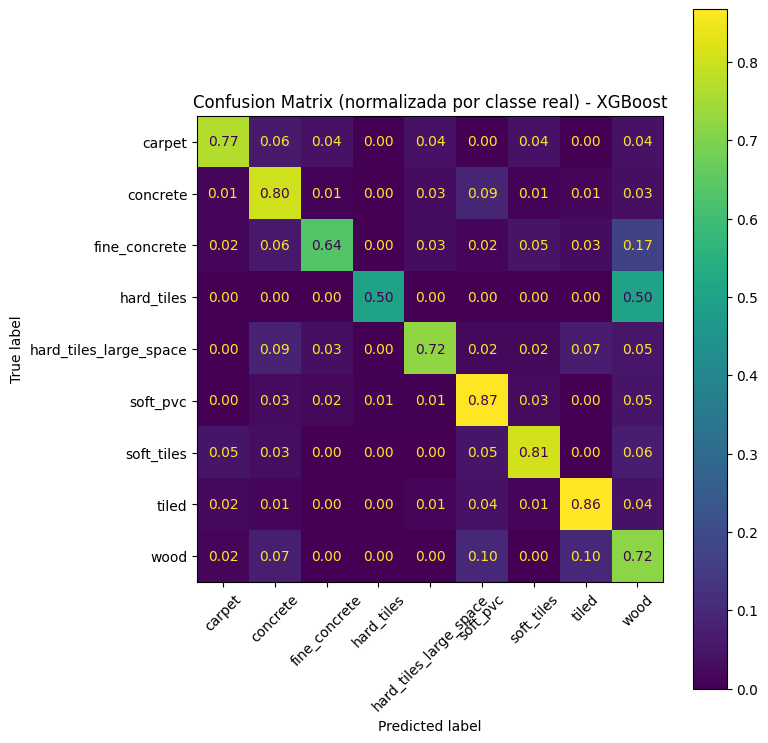

In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)
y_test  = le.transform(y_test)

best_model = None
best_evals_result = None
results = []


#funcao objetivo do optuna com a grid
def objective(trial):
    global best_model, best_evals_result, results

    params = {
        "max_depth":        trial.suggest_categorical("max_depth",        [6, 8, 10, 12]),
        "learning_rate":    trial.suggest_categorical("learning_rate",    [0.05, 0.1, 0.2]),
        "n_estimators":     trial.suggest_categorical("n_estimators",     [400, 600, 900]),
        "subsample":        trial.suggest_categorical("subsample",        [0.9, 1.0]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.8, 0.9, 1.0]),
        "reg_alpha":        trial.suggest_categorical("reg_alpha",        [0.0, 0.01, 0.05]),
        "reg_lambda":       trial.suggest_categorical("reg_lambda",       [0.1, 0.5, 1.0]),
        "min_child_weight": trial.suggest_categorical("min_child_weight", [1]),
        "gamma":            trial.suggest_categorical("gamma",            [0.0, 0.01, 0.05]),
        "random_state": 42,
        "eval_metric": "mlogloss"
    }

    model = xgb.XGBClassifier(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val), (X_test, y_test)],
        verbose=False
    )

    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    acc_train = accuracy_score(y_train, pred_train)
    f1_train  = f1_score(y_train, pred_train, average="macro")

    acc_val = accuracy_score(y_val, pred_val)
    f1_val  = f1_score(y_val, pred_val, average="macro")

    acc_test = accuracy_score(y_test, pred_test)
    f1_test  = f1_score(y_test, pred_test, average="macro")

    results.append({
        "trial": trial.number,
        "params": params,
        "train_acc": acc_train,
        "train_f1_macro": f1_train,
        "val_acc": acc_val,
        "val_f1_macro": f1_val,
        "test_acc": acc_test,
        "test_f1_macro": f1_test
    })

    print(
        f"Trial {trial.number} | "
        f"TRAIN Acc: {acc_train:.4f} F1: {f1_train:.4f} | "
        f"VAL Acc: {acc_val:.4f} F1: {f1_val:.4f} | "
        f"TEST Acc: {acc_test:.4f} F1: {f1_test:.4f}"
    )

    if trial.number == 0 or f1_val > study.best_value if "study" in globals() and len(study.trials) > 0 else True:
        best_model = model
        best_evals_result = model.evals_result()

    return f1_val


#roda optuna
study = optuna.create_study(direction="maximize")

# ponto de partida agressivo: modelo complexo, pouca regularizacao
study.enqueue_trial({
    "max_depth": 8,
    "learning_rate": 0.1,
    "n_estimators": 600,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.1,
    "min_child_weight": 1,
    "gamma": 0.0
})

study.optimize(objective, n_trials=25)


# MELHORES PARAMETROS
print("\n==============================")
print("BEST PARAMS:", study.best_params)
print("BEST VALIDATION F1 (macro):", round(study.best_value, 4))
print("==============================\n")


# retreinar melhor modelo com os melhores parametros e avaliar no test set

best_params = study.best_params.copy()
best_params["random_state"] = 42
best_params["eval_metric"] = "mlogloss"

best_model = xgb.XGBClassifier(**best_params)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val), (X_test, y_test)],
    verbose=False
)

best_evals_result = best_model.evals_result()


#avalicao final no test set -
pred_test = best_model.predict(X_test)

acc_test = accuracy_score(y_test, pred_test)
f1_test  = f1_score(y_test, pred_test, average="macro")

print("FINAL TEST RESULTS")
print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test F1 (macro): {f1_test:.4f}")


#classificacaao da importancia de cada feature
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 20 Features:")
print(feat_imp.head(20))


#confusion matrix normalizada
cm_norm = confusion_matrix(y_test, pred_test, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, values_format=".2f")
plt.title("Confusion Matrix (normalizada por classe real) - XGBoost")
plt.tight_layout()
plt.show()


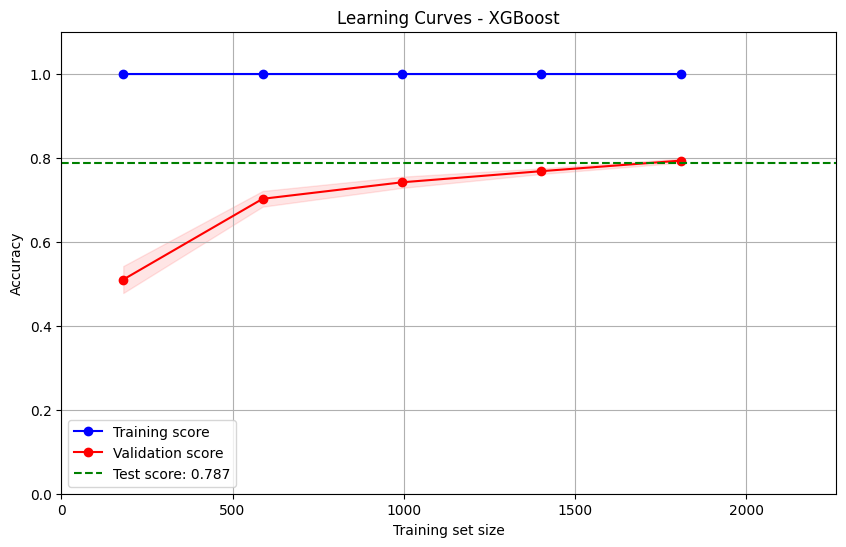

In [10]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

test_score = accuracy_score(y_test, best_model.predict(X_test))

plt.figure(figsize=(10, 6))
plt.xlim(0, len(X_train))
plt.ylim(0, 1.1)
plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_mean, "o-", color="red", label="Validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="red")
plt.axhline(y=test_score, color="green", linestyle="--", label=f"Test score: {test_score:.3f}")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curves - XGBoost")
plt.legend(loc="best")
plt.grid(True)
plt.show()


## Análise de viés e variância

O modelo apresenta **baixíssimo viés e alta variância**: a curva de treino sobe muito acima da de validação, overfitando claramente o training set.

Isso não é necessariamente um problema. Um modelo que overfita o treino mas ainda entrega bom F1 em validação e teste é superior a um modelo "bem comportado" que não overfita mas acerta menos. O gap entre treino e val indica que há capacidade não aproveitada — mais dados ou mais regularização poderiam fechar essa diferença — mas o desempenho no test set já é sólido.

Modelos com alto viés têm um teto estruturalmente baixo. Modelos com alta variância, como este, têm margem de melhora.

In [ ]:
dataset_filtrado.head()